# Exploratory Data Analysis (EDA)
## Indian Food Delivery App Sentiment Intelligence System

---
This notebook performs visual analysis of the collected review data
to understand patterns, distributions and key insights before model building.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 1. Data Loading & Validation

Loading preprocessed data and handling any remaining missing values
before starting the analysis.

In [4]:
df = pd.read_csv(r"C:\Users\Dell\Data_Science_Project\05_NLP_Sentiments_Project\Data\Processed\processed_reviews.csv")
print("Data loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully!
Shape: (1500, 9)


,username,review,rating,date,app,cleaned_review,processed_review,sentiment,rating_sentiment
0,Sanjoy Manna,vijj,1,2026-03-12 02:48:43,Zomato,vijj,vijj,Neutral,Negative
1,Sherin.S sherin,very good,5,2026-03-12 02:47:09,Zomato,very good,good,Positive,Positive
2,Ningreithem Moilee,Plenty of options to choose anytime anywhere.,5,2026-03-12 02:45:45,Zomato,plenty of options to choose anytime anywhere,plenty option choose anytime anywhere,Neutral,Positive
3,Md tunna,good,5,2026-03-12 02:30:00,Zomato,good,good,Positive,Positive
4,Naresh Kumar,ok,5,2026-03-12 02:25:01,Zomato,ok,NaN,Neutral,Positive


In [5]:
df['processed_review'] = df['processed_review'].fillna(df['cleaned_review'])

print("NaN values after fix:")
print(df.isnull().sum())

NaN values after fix:
username             0
review               0
rating               0
date                 0
app                  0
cleaned_review      41
processed_review    41
sentiment            0
rating_sentiment     0
dtype: int64


In [6]:
print(f"\nTotal rows: {len(df)}")


Total rows: 1500


In [7]:
df = df.dropna(subset=['cleaned_review', 'processed_review'])

In [8]:
df = df.reset_index(drop=True)

In [9]:
print("After removing NaN values:")
print(f"Total rows remaining: {len(df)}")
print("\nNaN check:")
print(df.isnull().sum())

After removing NaN values:
Total rows remaining: 1459

NaN check:
username            0
review              0
rating              0
date                0
app                 0
cleaned_review      0
processed_review    0
sentiment           0
rating_sentiment    0
dtype: int64


In [10]:
df.to_csv(r'C:\Users\Dell\Data_Science_Project\05_NLP_Sentiments_Project\Data\processed/processed_reviews.csv', index=False)

print("Data saved successfully!")
print(f"Final shape: {df.shape}")

Data saved successfully!
Final shape: (1459, 9)


## 2. Rating Distribution Analysis

Analyzing how customers rate the three food delivery apps
both individually and in comparison.

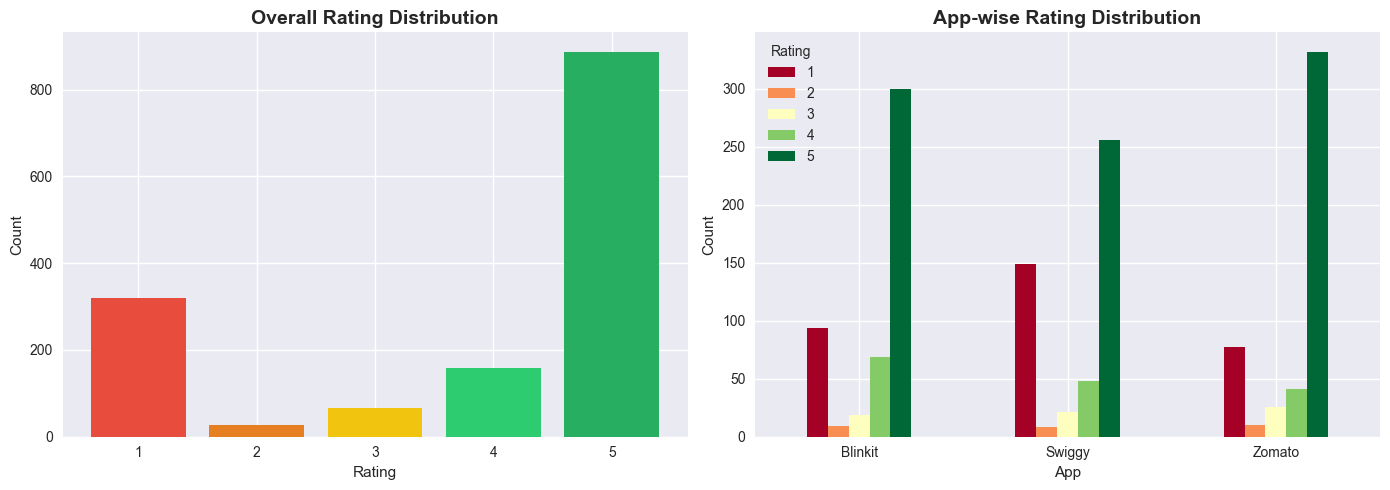

Graph saved successfully!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(df['rating'].value_counts().sort_index().index,
            df['rating'].value_counts().sort_index().values,
            color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'])
axes[0].set_title('Overall Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
app_rating = df.groupby(['app', 'rating']).size().unstack()
app_rating.plot(kind='bar', ax=axes[1], colormap='RdYlGn')
axes[1].set_title('App-wise Rating Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('App')
axes[1].set_ylabel('Count')
axes[1].legend(title='Rating')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(r'C:\Users\Dell\Data_Science_Project\05_NLP_Sentiments_Project\Data\Visuals/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved successfully!")

## 3. Sentiment Distribution Analysis

Comparing VADER based NLP sentiment vs Rating based sentiment
to understand customer behavior patterns.

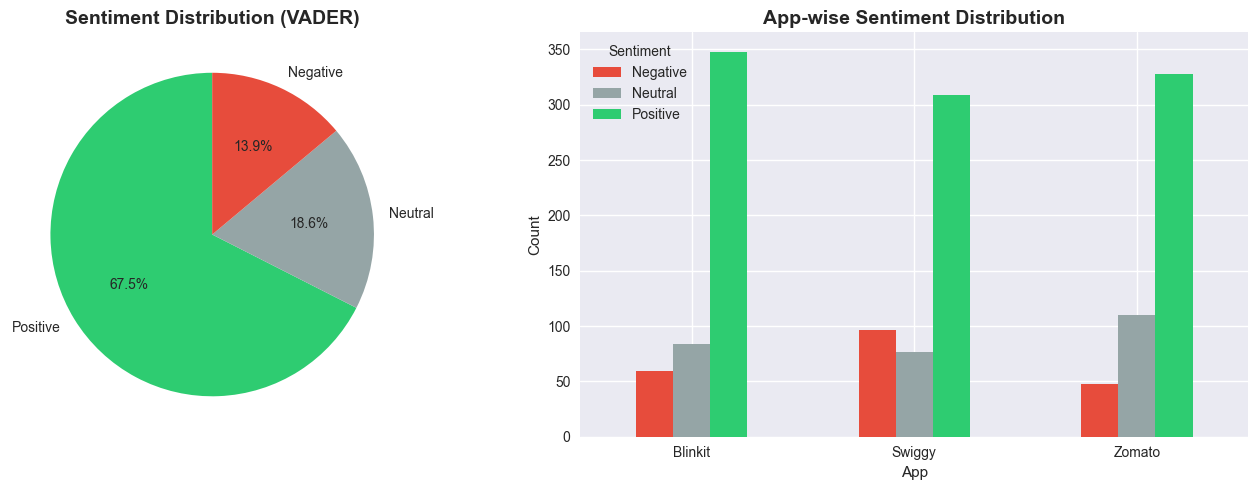

Graph saved successfully!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sentiment_counts = df['sentiment'].value_counts()
axes[0].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=['#2ecc71', '#95a5a6', '#e74c3c'],
            startangle=90)
axes[0].set_title('Sentiment Distribution (VADER)', 
                   fontsize=14, fontweight='bold')
app_sentiment = df.groupby(['app', 'sentiment']).size().unstack()
app_sentiment.plot(kind='bar', ax=axes[1], 
                   color=['#e74c3c', '#95a5a6', '#2ecc71'])
axes[1].set_title('App-wise Sentiment Distribution', 
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('App')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/sentiment_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved successfully!")

## 4. Word Cloud Analysis

Visualizing most frequently used words in reviews for each app
to identify common themes and topics.

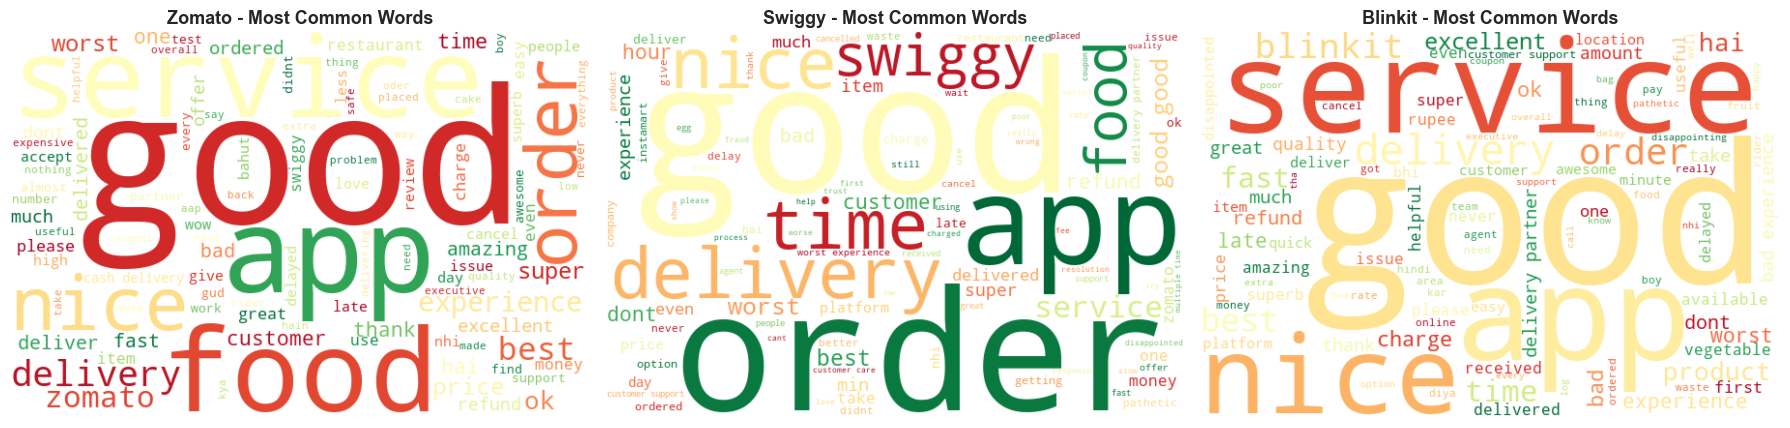

Wordcloud saved successfully!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

apps = ['Zomato', 'Swiggy', 'Blinkit']

for idx, app in enumerate(apps):
    
    text = ' '.join(df[df['app'] == app]['processed_review'].dropna())
    wordcloud = WordCloud(
        width=600, 
        height=400,
        background_color='white',
        colormap='RdYlGn',
        max_words=100
    ).generate(text)
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{app} - Most Common Words', 
                         fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/wordcloud.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Wordcloud saved successfully!")

## 5. Review Length Analysis

Analyzing relationship between review length and sentiment.
**Hypothesis:** Negative reviewers tend to write longer reviews
to explain their complaints in detail.

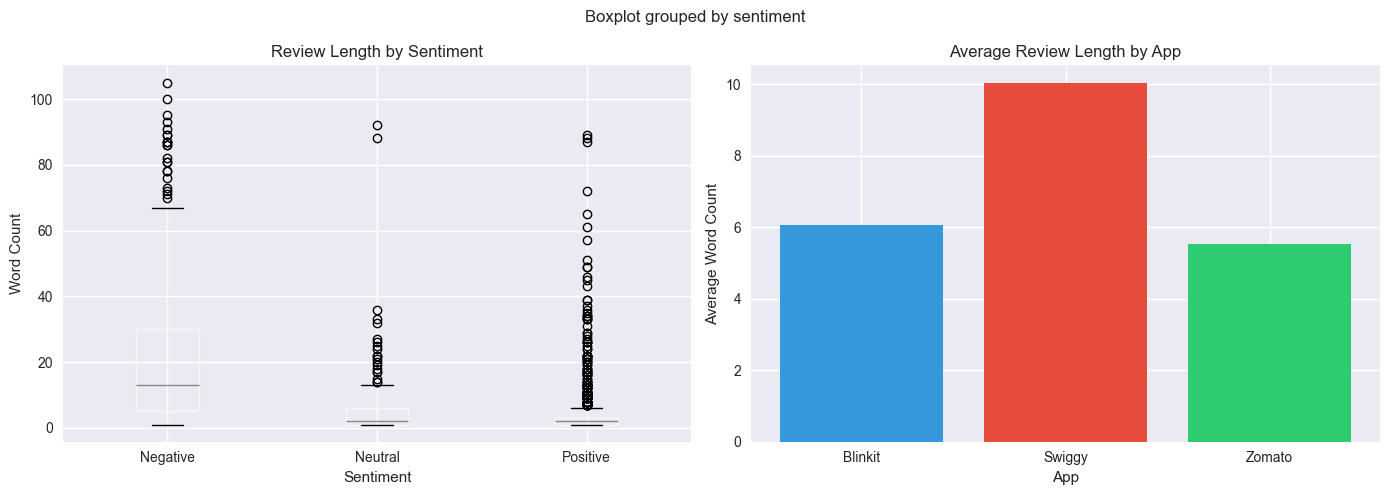

Graph saved successfully!


In [16]:
df['review_length'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='review_length', by='sentiment', ax=axes[0])
axes[0].set_title('Review Length by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Word Count')
app_length = df.groupby('app')['review_length'].mean()
axes[1].bar(app_length.index, app_length.values,
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('Average Review Length by App')
axes[1].set_xlabel('App')
axes[1].set_ylabel('Average Word Count')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/review_length.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved successfully!")

## 6. Feature Engineering

Converting processed text to numerical features using TF-IDF Vectorization
for machine learning model training.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
tfidf = TfidfVectorizer(
    max_features=5000,   
    ngram_range=(1, 2),  
    min_df=2,            
    max_df=0.95         
)

X = tfidf.fit_transform(df['processed_review'])
y = df['sentiment']

print("Feature Engineering Done!")
print(f"Feature Matrix Shape: {X.shape}")
print(f"\nTarget Distribution:")
print(y.value_counts())

Feature Engineering Done!
Feature Matrix Shape: (1459, 916)

Target Distribution:
sentiment
Positive    985
Neutral     271
Negative    203
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [20]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label Encoding:")
for i, class_ in enumerate(le.classes_):
    print(f"{class_} = {i}")

Label Encoding:
Negative = 0
Neutral = 1
Positive = 2


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")


Training set size: 1167
Testing set size: 292


In [23]:
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution in Training Set:")
for u, c in zip(le.classes_, counts):
    print(f"{u}: {c}")


Class Distribution in Training Set:
Negative: 162
Neutral: 217
Positive: 788


## 7. Model Building & Comparison

Training and comparing 5 ML models to find the best performer
for sentiment classification.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              accuracy_score)

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [25]:
model_results = {}
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

model_results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, lr_pred),
    'predictions': lr_pred
}
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.8699


In [26]:
print("\nTraining Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

model_results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, dt_pred),
    'predictions': dt_pred
}
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")


Training Decision Tree...
Decision Tree Accuracy: 0.7363


In [30]:
print("\nTraining Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
model_results['Naive Bayes'] = {
    'accuracy': accuracy_score(y_test, nb_pred),
    'predictions': nb_pred
}
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_pred):.4f}")


Training Naive Bayes...
Naive Bayes Accuracy: 0.8664


In [31]:
print("\nTraining SVM...")
svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
model_results['SVM'] = {
    'accuracy': accuracy_score(y_test, svm_pred),
    'predictions': svm_pred
}
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")


Training SVM...
SVM Accuracy: 0.8973


In [27]:
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

model_results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, rf_pred),
    'predictions': rf_pred
}
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

print("\nAll ML Models Trained Successfully!")


Training Random Forest...
Random Forest Accuracy: 0.9110

All ML Models Trained Successfully!


In [32]:
models = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Naive Bayes': nb_pred,
    'SVM': svm_pred,
    'Random Forest': rf_pred
}

for model_name, predictions in models.items():
    print("=" * 55)
    print(f"Model: {model_name}")
    print("=" * 55)
    print(classification_report(
        y_test, 
        predictions,
        target_names=le.classes_
    ))

Model: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.65      0.83      0.73        41
     Neutral       0.71      0.89      0.79        54
    Positive       1.00      0.87      0.93       197

    accuracy                           0.87       292
   macro avg       0.79      0.86      0.82       292
weighted avg       0.90      0.87      0.88       292

Model: Decision Tree
              precision    recall  f1-score   support

    Negative       0.86      0.59      0.70        41
     Neutral       0.41      0.94      0.58        54
    Positive       0.99      0.71      0.83       197

    accuracy                           0.74       292
   macro avg       0.75      0.75      0.70       292
weighted avg       0.87      0.74      0.76       292

Model: Naive Bayes
              precision    recall  f1-score   support

    Negative       0.74      0.83      0.78        41
     Neutral       0.84      0.59      0.70        54
    Posi

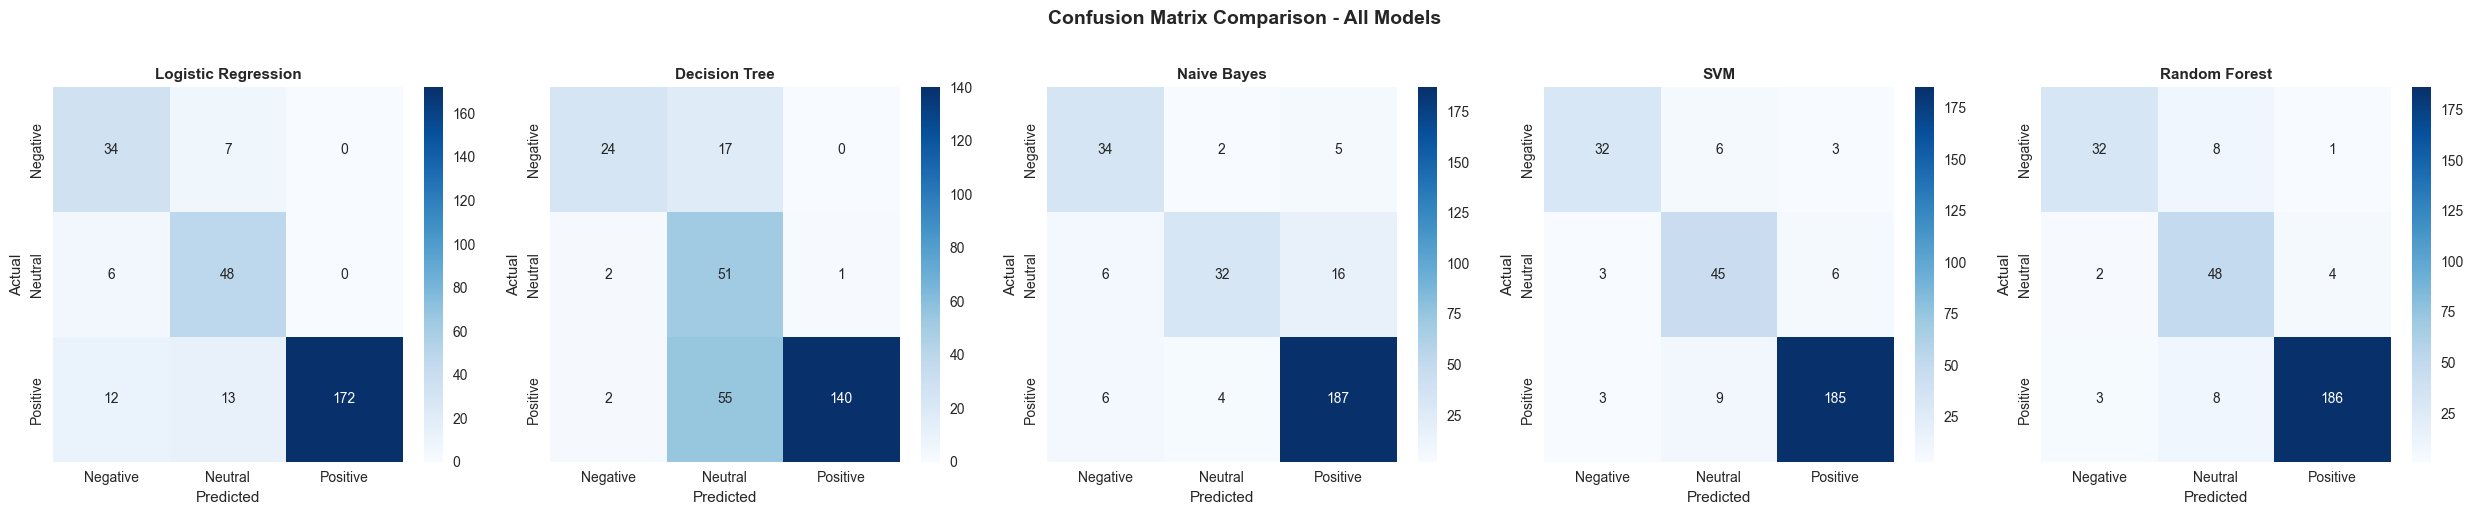

Confusion Matrix saved successfully!


In [34]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
models_dict = {
    'Logistic Regression': lr_pred,
    'Decision Tree': dt_pred,
    'Naive Bayes': nb_pred,
    'SVM': svm_pred,
    'Random Forest': rf_pred
}
for idx, (model_name, predictions) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison - All Models', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Confusion Matrix saved successfully!")

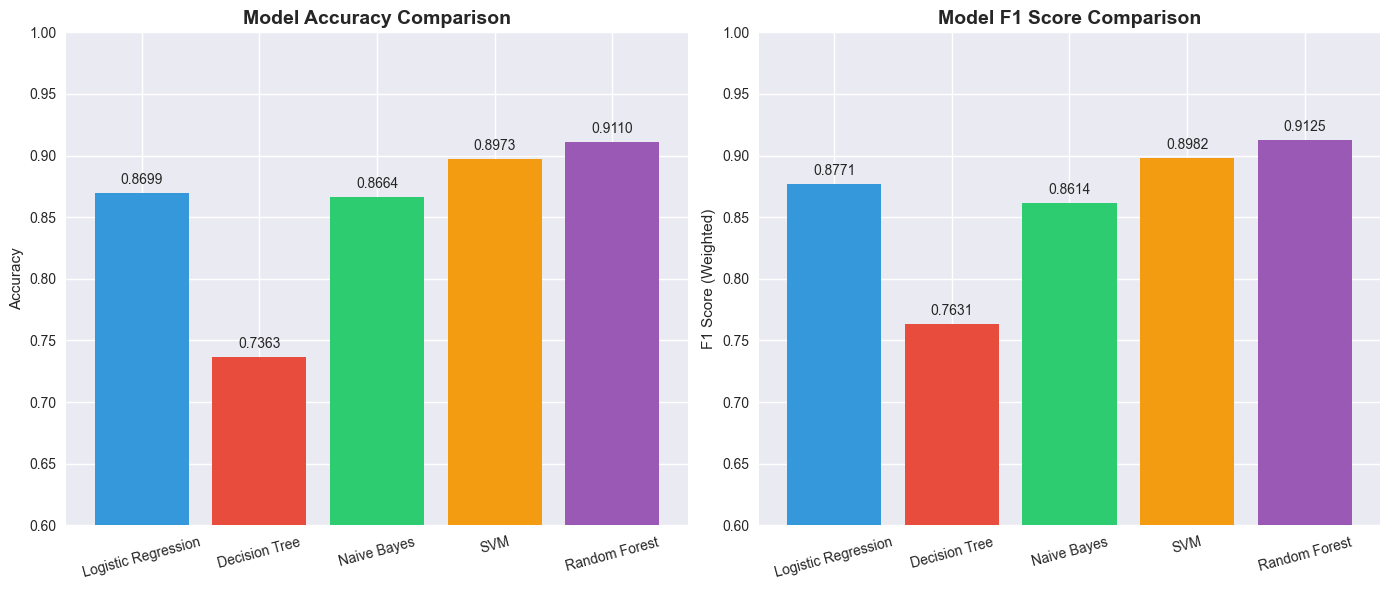

Model Comparison Chart saved successfully!


In [35]:
model_names = list(models_dict.keys())
accuracies = [accuracy_score(y_test, pred) 
              for pred in models_dict.values()]
from sklearn.metrics import f1_score
f1_scores = [f1_score(y_test, pred, average='weighted') 
             for pred in models_dict.values()]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bars1 = axes[0].bar(model_names, accuracies, 
                     color=['#3498db', '#e74c3c', 
                            '#2ecc71', '#f39c12', '#9b59b6'])
axes[0].set_title('Model Accuracy Comparison', 
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.6, 1.0)
axes[0].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., 
                 bar.get_height() + 0.005,
                 f'{acc:.4f}', ha='center', 
                 va='bottom', fontsize=10)
bars2 = axes[1].bar(model_names, f1_scores,
                     color=['#3498db', '#e74c3c', 
                            '#2ecc71', '#f39c12', '#9b59b6'])
axes[1].set_title('Model F1 Score Comparison', 
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Score (Weighted)')
axes[1].set_ylim(0.6, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., 
                 bar.get_height() + 0.005,
                 f'{f1:.4f}', ha='center', 
                 va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('C:/Users/Dell/Data_Science_Project/05_NLP_Sentiments_Project/Data/Visuals/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Model Comparison Chart saved successfully!")

## 8. Key Observations

- **Best Model:** Random Forest with 91.10% accuracy
- **Delivery Issues** are the #1 complaint across all apps
- **Negative reviewers** write significantly longer reviews
- **Swiggy** has highest negative sentiment (19.9%)
- **Zomato** has best customer satisfaction score (4.11/5)

**Next:** Proceed to 03_Deep_Learning for ANN and Perceptron models.